# Stock Financial Health Analyzer

**Student Name:** [Xinchen.Wang]  
**Student ID:** [2470712]  
**Module Code:** ACC102  
**Track:** Track 4 – Interactive Data Analysis Tool  
**Data Access Date:** [ 18 April 2026]  

## AI Disclosure
This notebook was developed with limited support from AI tools such as ChatGPT on [April/2026] for:
- improving code structure
- debugging parts of the workflow
- refining documentation and explanations

All final decisions, testing, integration with the Streamlit product, and analytical interpretation were completed by me.

## 1. Problem Definition

This project addresses the following analytical problem:

**How can users evaluate a company more effectively by combining stock price trends, selected financial health indicators, and recent market news in one interactive dashboard?**

### Target Users
The target users are:
- students studying accounting, finance, or business
- beginner investors
- non-specialist users interested in stock analysis

### Business and Financial Value
This problem is important because stock prices alone do not provide a full picture of a company’s performance. Financial indicators such as liquidity, solvency, profitability, and growth help users understand the underlying financial condition of a company. News context also helps users interpret short-term market movement.

### Why This Problem Is Worth Analysing
Many public financial websites provide large amounts of data, but they often lack a simple, integrated, and beginner-friendly structure. This project aims to transform raw financial data into a more interpretable decision-support product.

## 2. Dataset Information

### Main Data Source
This project mainly uses **Yahoo Finance** data retrieved through the `yfinance` Python library.

### Data Retrieval Date
Data was accessed on **[replace with your actual access date]**.

### Types of Data Used
The project uses:
- historical stock price data
- company financial information
- company-related news
- broader market news

### Coverage
- **Companies:** selected large listed companies across multiple sectors
- **Sectors included:**
  - Technology
  - Communication Services
  - Consumer
  - Financial Services
  - Healthcare
  - Energy
  - Industrials
- **Periods available:** 1 month, 3 months, 6 months, 1 year, 5 years, 10 years

### Key Variables
- Open
- High
- Low
- Close
- Volume
- Market Cap
- Trailing P/E
- Revenue Growth
- Profit Margins
- Current Ratio
- Debt to Equity

### Local Fallback Data
To improve stability and reproducibility, local CSV files are used as fallback sources when live data retrieval fails.

### Why This Dataset Was Chosen
Yahoo Finance is suitable because it provides public financial data in a form that supports:
- price trend analysis
- company financial evaluation
- integration of news into the analytical workflow

This makes it appropriate for an interactive educational finance dashboard.

## 3. Data Dictionary

| Variable | Meaning |
|---|---|
| Open | Opening stock price for the trading day |
| High | Highest stock price during the trading day |
| Low | Lowest stock price during the trading day |
| Close | Closing stock price for the trading day |
| Volume | Number of shares traded |
| Market Cap | Total market value of the company’s outstanding shares |
| Trailing P/E | Price-to-earnings ratio based on trailing earnings |
| Revenue Growth | Growth rate of company revenue |
| Profit Margins | Net profit as a proportion of revenue |
| Current Ratio | Current assets divided by current liabilities |
| Debt to Equity | Total debt relative to shareholder equity |

In [7]:
import sys
print(sys.executable)

c:\Users\王馨晨\Desktop\stock-financial-health-analyzer\.venv\Scripts\python.exe


In [8]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\王馨晨\Desktop\stock-financial-health-analyzer\.venv\Scripts\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

print("all good")

all good


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [11]:
import os
import time
import datetime
import threading
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")

In [12]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")

## 4. Python Workflow

This notebook follows the same analytical workflow as the Streamlit product:

1. Import libraries  
2. Retrieve stock data and company information  
3. Inspect data quality  
4. Clean and transform the data  
5. Calculate key performance metrics  
6. Evaluate financial dimensions  
7. Visualise results  
8. Prepare outputs that support the Streamlit dashboard

### 4.1 Define Company Universe and Input Settings

In [13]:
company_data = {
    "Technology": {
        "Apple Inc. (AAPL)": "AAPL",
        "Microsoft Corporation (MSFT)": "MSFT",
        "NVIDIA Corporation (NVDA)": "NVDA"
    },
    "Communication Services": {
        "Alphabet Inc. (GOOGL)": "GOOGL",
        "Meta Platforms Inc. (META)": "META",
        "Walt Disney Company (DIS)": "DIS",
        "Netflix Inc. (NFLX)": "NFLX",
        "Verizon Communications Inc. (VZ)": "VZ"
    },
    "Consumer": {
        "Amazon.com Inc. (AMZN)": "AMZN",
        "Tesla Inc. (TSLA)": "TSLA",
        "McDonald's Corporation (MCD)": "MCD",
        "Coca-Cola Company (KO)": "KO",
        "PepsiCo Inc. (PEP)": "PEP"
    },
    "Financial Services": {
        "JPMorgan Chase & Co. (JPM)": "JPM",
        "Bank of America Corporation (BAC)": "BAC",
        "Goldman Sachs Group Inc. (GS)": "GS",
        "Citigroup Inc. (C)": "C",
        "Wells Fargo & Company (WFC)": "WFC"
    },
    "Healthcare": {
        "Johnson & Johnson (JNJ)": "JNJ",
        "Pfizer Inc. (PFE)": "PFE",
        "Merck & Co. Inc. (MRK)": "MRK",
        "AbbVie Inc. (ABBV)": "ABBV",
        "UnitedHealth Group Incorporated (UNH)": "UNH"
    },
    "Energy": {
        "Exxon Mobil Corporation (XOM)": "XOM",
        "Chevron Corporation (CVX)": "CVX",
        "ConocoPhillips (COP)": "COP"
    },
    "Industrials": {
        "Caterpillar Inc. (CAT)": "CAT",
        "Boeing Company (BA)": "BA",
        "GE Aerospace (GE)": "GE",
        "Honeywell International Inc. (HON)": "HON"
    }
}

selected_sector = "Industrials"
selected_company = "Caterpillar Inc. (CAT)"
ticker = company_data[selected_sector][selected_company]
period = "6mo"

ticker, period

('CAT', '6mo')

### 4.2 Data Retrieval

In [14]:
stock = yf.Ticker(ticker)
hist = stock.history(period=period)
info = stock.info

In [15]:
print("Historical data shape:", hist.shape)
print("Info dictionary keys sample:", list(info.keys())[:20] if isinstance(info, dict) else "No info available")

Historical data shape: (124, 7)
Info dictionary keys sample: ['address1', 'address2', 'city', 'state', 'zip', 'country', 'phone', 'fax', 'website', 'industry', 'industryKey', 'industryDisp', 'sector', 'sectorKey', 'sectorDisp', 'longBusinessSummary', 'fullTimeEmployees', 'companyOfficers', 'auditRisk', 'boardRisk']


### 4.3 Data Inspection
The next step checks the structure, missing values, and summary statistics of the stock price dataset.

In [16]:
hist.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-10-20 00:00:00-04:00,528.323850,532.953033,525.709971,529.940063,2170800,1.51,0.0
2025-10-21 00:00:00-04:00,523.844357,532.134956,520.821400,523.425354,2259100,0.00,0.0
2025-10-22 00:00:00-04:00,524.502805,524.572649,509.019043,512.710388,4149000,0.00,0.0
2025-10-23 00:00:00-04:00,517.120117,521.669470,511.812527,519.285034,2619400,0.00,0.0
2025-10-24 00:00:00-04:00,521.639528,525.999323,519.803857,521.509827,2392000,0.00,0.0


In [17]:
hist.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 124 entries, 2025-10-20 00:00:00-04:00 to 2026-04-17 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          124 non-null    float64
 1   High          124 non-null    float64
 2   Low           124 non-null    float64
 3   Close         124 non-null    float64
 4   Volume        124 non-null    int64  
 5   Dividends     124 non-null    float64
 6   Stock Splits  124 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 7.8 KB


In [18]:
hist.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,124.000000,124.000000,124.000000,124.000000,1.240000e+02,124.000000,124.0
mean,646.390914,656.444003,637.171993,647.766341,2.697403e+06,0.024355,0.0
std,80.189306,82.266645,78.618062,81.150244,1.022676e+06,0.190989,0.0
min,517.120117,521.669470,509.019043,512.710388,9.470000e+05,0.000000,0.0
25%,575.610726,582.571965,569.125906,575.653137,2.032925e+06,0.000000,0.0
50%,635.819977,644.114990,626.220001,636.589508,2.559300e+06,0.000000,0.0
75%,712.960022,726.147491,703.790009,716.814987,3.127575e+06,0.000000,0.0
max,796.000000,801.770020,786.239990,794.650024,7.146700e+06,1.510000,0.0


In [19]:
hist.isna().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [20]:
hist.index.duplicated().sum()


np.int64(0)

### 4.4 Helper Functions for Data Cleaning and Formatting
These functions are reused in the Streamlit app to keep the notebook and product logic consistent.

In [21]:
def clean_numeric(value):
    if value is None:
        return None
    if isinstance(value, str):
        if value.strip().upper() in ["N/A", "NONE", "", "NAN"]:
            return None
        try:
            return float(value)
        except Exception:
            return None
    if pd.isna(value):
        return None
    if isinstance(value, (int, float)):
        return float(value)
    return None


def format_value(value, percentage=False):
    value = clean_numeric(value)
    if value is None:
        return "Data not available"

    if percentage:
        return f"{value * 100:.2f}%"

    if abs(value) >= 1e12:
        return f"{value / 1e12:.2f}T"
    elif abs(value) >= 1e9:
        return f"{value / 1e9:.2f}B"
    elif abs(value) >= 1e6:
        return f"{value / 1e6:.2f}M"
    else:
        return f"{value:,.2f}"

### 4.5 Extract Financial Indicators

In [22]:
financial_summary = {
    "longName": info.get("longName"),
    "sector": info.get("sector"),
    "industry": info.get("industry"),
    "marketCap": clean_numeric(info.get("marketCap")),
    "trailingPE": clean_numeric(info.get("trailingPE")),
    "revenueGrowth": clean_numeric(info.get("revenueGrowth")),
    "profitMargins": clean_numeric(info.get("profitMargins")),
    "currentRatio": clean_numeric(info.get("currentRatio")),
    "debtToEquity": clean_numeric(info.get("debtToEquity"))
}

financial_summary

{'longName': 'Caterpillar Inc.',
 'sector': 'Industrials',
 'industry': 'Farm & Heavy Construction Machinery',
 'marketCap': 371880001536.0,
 'trailingPE': 42.201275,
 'revenueGrowth': 0.18,
 'profitMargins': 0.13144,
 'currentRatio': 1.436,
 'debtToEquity': 206.67}

In [23]:
financial_df = pd.DataFrame([financial_summary])
financial_df

,longName,sector,industry,marketCap,trailingPE,revenueGrowth,profitMargins,currentRatio,debtToEquity
0,Caterpillar Inc.,Industrials,Farm & Heavy Construction Machinery,3.718800e+11,42.201275,0.18,0.13144,1.436,206.67


### 4.6 Feature Engineering
The stock price data is transformed into more interpretable metrics, including moving averages and price change indicators.

In [24]:
hist = hist.copy()
hist["MA20"] = hist["Close"].rolling(window=20).mean()
hist["MA50"] = hist["Close"].rolling(window=50).mean()

latest_close = float(hist["Close"].iloc[-1])
first_close = float(hist["Close"].iloc[0])
price_change = latest_close - first_close
price_change_pct = (price_change / first_close) * 100 if first_close != 0 else 0
avg_volume = float(hist["Volume"].mean()) if "Volume" in hist.columns else None

summary_metrics = {
    "Latest Close": latest_close,
    "First Close": first_close,
    "Price Change": price_change,
    "Price Change %": price_change_pct,
    "Average Volume": avg_volume
}

summary_metrics

{'Latest Close': 794.6500244140625,
 'First Close': 529.9400634765625,
 'Price Change': 264.7099609375,
 'Price Change %': 49.950924487747706,
 'Average Volume': 2697403.2258064514}

### 4.7 Rule-Based Financial Evaluation
The project evaluates four dimensions of financial health:
- Liquidity
- Solvency
- Profitability
- Growth

In [25]:
def evaluate_liquidity(current_ratio):
    current_ratio = clean_numeric(current_ratio)
    if current_ratio is None:
        return "Liquidity could not be assessed because the current ratio is not available."
    if current_ratio >= 1.5:
        return "The company shows a good liquidity position."
    elif current_ratio >= 1.0:
        return "The company has an acceptable liquidity position."
    else:
        return "The company may have a relatively weak liquidity position."


def evaluate_solvency(debt_to_equity):
    debt_to_equity = clean_numeric(debt_to_equity)
    if debt_to_equity is None:
        return "Solvency could not be assessed because debt-to-equity data is not available."
    if debt_to_equity < 50:
        return "The company appears to have a relatively low debt burden."
    elif debt_to_equity < 100:
        return "The company has a moderate debt level."
    else:
        return "The company may have relatively high leverage."


def evaluate_profitability(profit_margins):
    profit_margins = clean_numeric(profit_margins)
    if profit_margins is None:
        return "Profitability could not be assessed because profit margin data is not available."
    if profit_margins > 0.20:
        return "The company shows strong profitability."
    elif profit_margins > 0.10:
        return "The company shows decent profitability."
    else:
        return "The company’s profitability appears relatively weak."


def evaluate_growth(revenue_growth):
    revenue_growth = clean_numeric(revenue_growth)
    if revenue_growth is None:
        return "Growth could not be assessed because revenue growth data is not available."
    if revenue_growth > 0.10:
        return "Revenue is growing strongly."
    elif revenue_growth > 0:
        return "Revenue is growing."
    else:
        return "Revenue growth is weak or negative."

In [26]:
liquidity_msg = evaluate_liquidity(financial_summary["currentRatio"])
solvency_msg = evaluate_solvency(financial_summary["debtToEquity"])
profitability_msg = evaluate_profitability(financial_summary["profitMargins"])
growth_msg = evaluate_growth(financial_summary["revenueGrowth"])

print("Liquidity:", liquidity_msg)
print("Solvency:", solvency_msg)
print("Profitability:", profitability_msg)
print("Growth:", growth_msg)

Liquidity: The company has an acceptable liquidity position.
Solvency: The company may have relatively high leverage.
Profitability: The company shows decent profitability.
Growth: Revenue is growing strongly.


### 4.8 Financial Health Scoring
The notebook applies the same scoring logic as the Streamlit tool in order to maintain consistency between the analytical backend and the interactive product.

In [27]:
def score_liquidity(current_ratio):
    current_ratio = clean_numeric(current_ratio)
    if current_ratio is None:
        return None
    if current_ratio >= 1.5:
        return 25
    elif current_ratio >= 1.0:
        return 18
    else:
        return 10


def score_solvency(debt_to_equity):
    debt_to_equity = clean_numeric(debt_to_equity)
    if debt_to_equity is None:
        return None
    if debt_to_equity < 50:
        return 25
    elif debt_to_equity < 100:
        return 18
    else:
        return 10


def score_profitability(profit_margins):
    profit_margins = clean_numeric(profit_margins)
    if profit_margins is None:
        return None
    if profit_margins > 0.20:
        return 25
    elif profit_margins > 0.10:
        return 18
    else:
        return 10


def score_growth(revenue_growth):
    revenue_growth = clean_numeric(revenue_growth)
    if revenue_growth is None:
        return None
    if revenue_growth > 0.15:
        return 25
    elif revenue_growth > 0:
        return 18
    else:
        return 10


def calculate_overall_score(current_ratio, debt_to_equity, profit_margins, revenue_growth):
    scores = {
        "Liquidity": score_liquidity(current_ratio),
        "Solvency": score_solvency(debt_to_equity),
        "Profitability": score_profitability(profit_margins),
        "Growth": score_growth(revenue_growth)
    }

    available_scores = [v for v in scores.values() if v is not None]

    if not available_scores:
        return None, scores

    if len(available_scores) == 4:
        overall_score = sum(available_scores)
    else:
        overall_score = round(sum(available_scores) / len(available_scores) * 4)

    return overall_score, scores


def score_label(score):
    if score is None:
        return "Unavailable"
    if score >= 85:
        return "Excellent"
    elif score >= 70:
        return "Good"
    elif score >= 50:
        return "Moderate"
    else:
        return "Weak"

In [28]:
overall_score, dimension_scores = calculate_overall_score(
    financial_summary["currentRatio"],
    financial_summary["debtToEquity"],
    financial_summary["profitMargins"],
    financial_summary["revenueGrowth"]
)

overall_score, dimension_scores, score_label(overall_score)

(71,
 {'Liquidity': 18, 'Solvency': 10, 'Profitability': 18, 'Growth': 25},
 'Good')

### 4.9 Visualisation 1: Closing Price Trend with Moving Averages

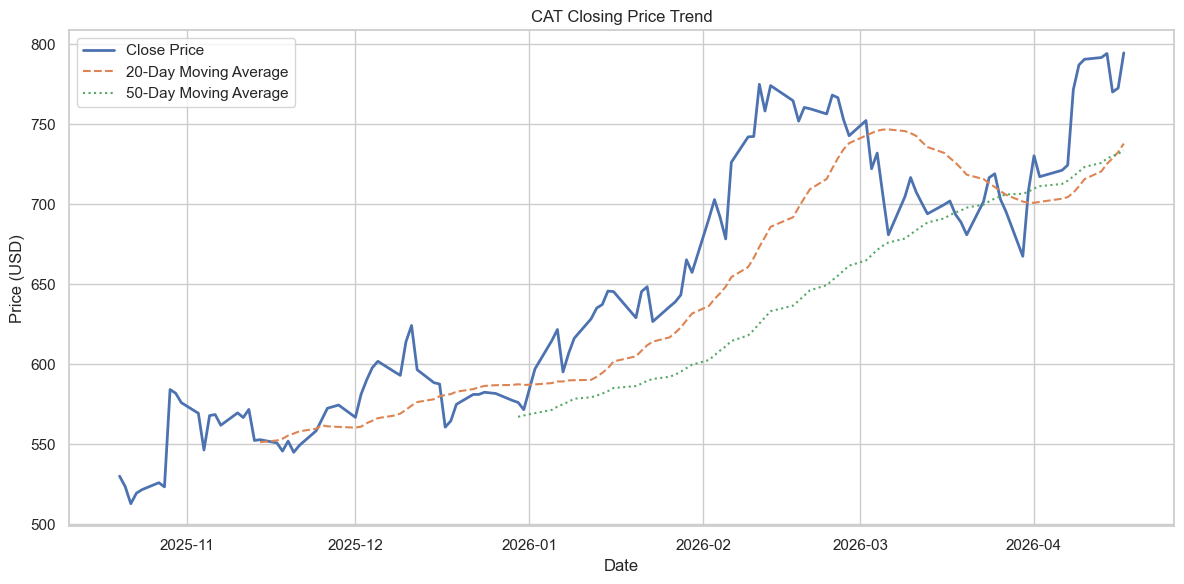

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(hist.index, hist["Close"], label="Close Price", linewidth=2)
plt.plot(hist.index, hist["MA20"], label="20-Day Moving Average", linestyle="--")
plt.plot(hist.index, hist["MA50"], label="50-Day Moving Average", linestyle=":")
plt.title(f"{ticker} Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

### 4.10 Visualisation 2: Trading Volume

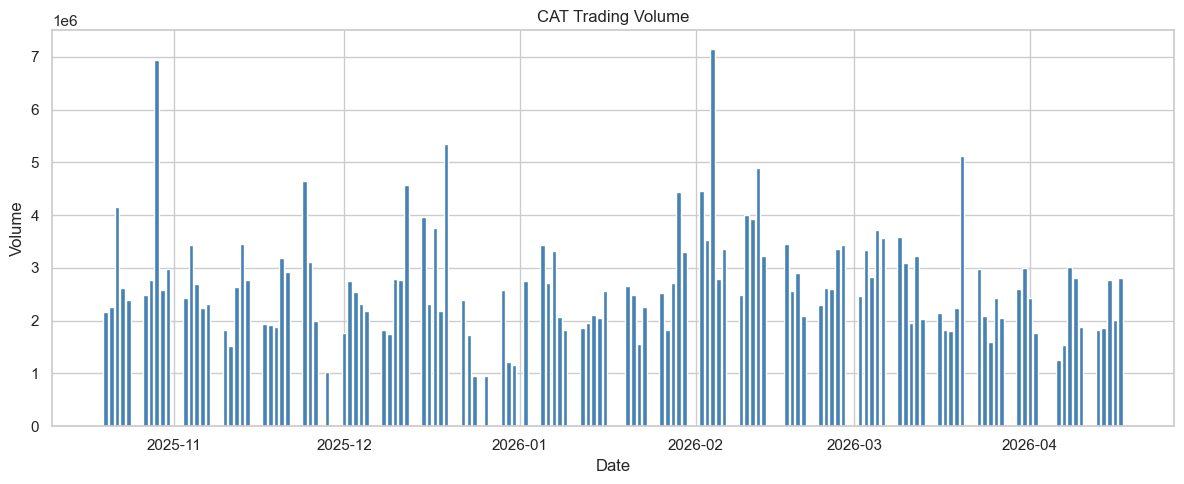

In [30]:
plt.figure(figsize=(12, 5))
plt.bar(hist.index, hist["Volume"], color="steelblue")
plt.title(f"{ticker} Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()

### 4.11 Visualisation 3: Financial Indicator Overview

In [31]:
plot_metrics = {
    "Trailing PE": clean_numeric(financial_summary["trailingPE"]),
    "Current Ratio": clean_numeric(financial_summary["currentRatio"]),
    "Debt to Equity": clean_numeric(financial_summary["debtToEquity"]),
    "Revenue Growth": clean_numeric(financial_summary["revenueGrowth"]) * 100 if clean_numeric(financial_summary["revenueGrowth"]) is not None else np.nan,
    "Profit Margins": clean_numeric(financial_summary["profitMargins"]) * 100 if clean_numeric(financial_summary["profitMargins"]) is not None else np.nan
}

plot_df = pd.DataFrame({
    "Metric": list(plot_metrics.keys()),
    "Value": list(plot_metrics.values())
})

plot_df

,Metric,Value
0,Trailing PE,42.201275
1,Current Ratio,1.436000
2,Debt to Equity,206.670000
3,Revenue Growth,18.000000
4,Profit Margins,13.144000


C:\Users\王馨晨\AppData\Local\Temp\ipykernel_29984\2176883727.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="Metric", y="Value", palette="viridis")


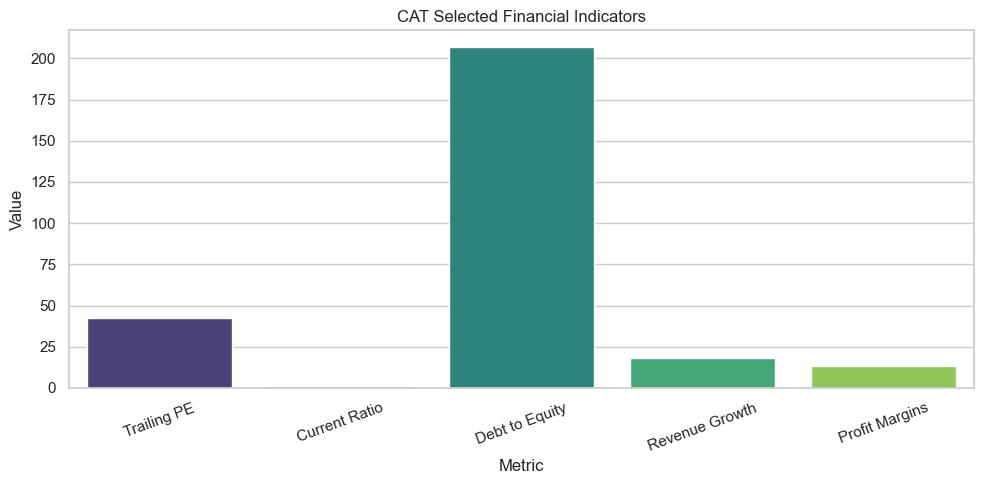

In [32]:
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Metric", y="Value", palette="viridis")
plt.title(f"{ticker} Selected Financial Indicators")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 4.12 News Data Retrieval
The Streamlit product includes both company-specific news and market-wide news. This notebook checks whether news data can be retrieved and parsed.

In [33]:
def format_news_time(raw_time):
    if raw_time is None:
        return "Unknown time"

    if isinstance(raw_time, (int, float)):
        try:
            dt = datetime.datetime.fromtimestamp(raw_time)
            return dt.strftime("%Y-%m-%d %H:%M")
        except Exception:
            return "Unknown time"

    if isinstance(raw_time, str):
        try:
            dt = datetime.datetime.fromisoformat(raw_time.replace("Z", "+00:00"))
            return dt.strftime("%Y-%m-%d %H:%M")
        except Exception:
            return raw_time

    return "Unknown time"


def parse_news_item(item):
    if not isinstance(item, dict):
        return {
            "title": "No title available",
            "publisher": "Unknown source",
            "link": None,
            "published": "Unknown time",
            "summary": "No summary available.",
            "related": []
        }

    content = item.get("content", {}) if isinstance(item.get("content", {}), dict) else {}

    title = item.get("title") or content.get("title") or "No title available"
    publisher = (
        item.get("publisher")
        or content.get("publisher")
        or content.get("provider", {}).get("displayName")
        or "Unknown source"
    )
    link = (
        item.get("link")
        or content.get("canonicalUrl", {}).get("url")
        or content.get("clickThroughUrl", {}).get("url")
        or None
    )
    raw_time = item.get("providerPublishTime") or content.get("pubDate") or item.get("pubDate")
    published = format_news_time(raw_time)
    summary = (
        item.get("summary")
        or content.get("summary")
        or content.get("description")
        or "No summary available."
    )
    related = item.get("relatedTickers") or content.get("relatedTickers") or []

    return {
        "title": title,
        "publisher": publisher,
        "link": link,
        "published": published,
        "summary": summary,
        "related": related
    }

In [34]:
raw_company_news = stock.news
parsed_company_news = [parse_news_item(item) for item in raw_company_news[:5]] if raw_company_news else []
pd.DataFrame(parsed_company_news)

,title,publisher,link,published,summary,related
0,"Trump eyes ""historic"" China summit as Xi welco...",Investing.com,https://finance.yahoo.com/economy/policy/artic...,2026-04-18 04:24,Investing.com -- President Donald Trump has si...,[]
1,Industrial Demand Holds Strong Despite Iran Wa...,MT Newswires,https://finance.yahoo.com/sectors/technology/a...,2026-04-17 20:29,The industrial sector likely saw strong demand...,[]
2,These Red Hot AI Infrastructure Stocks Keep Pa...,Zacks,https://finance.yahoo.com/markets/stocks/artic...,2026-04-17 15:30,Both Caterpillar and Eaton continue to deliver...,[]
3,Bloom Energy and Dave & Buster's have been hig...,Zacks,https://finance.yahoo.com/markets/stocks/artic...,2026-04-17 12:14,Bloom Energy surges on AI-driven data center d...,[]
4,"Why Boeing, GE Supplier Woodward Has Clear Ski...",Investor's Business Daily,https://www.investors.com/research/the-new-ame...,2026-04-17 12:00,Woodward's energy conversion and control syste...,[]


### 4.13 Output Preparation
This step prepares structured outputs that can be reused directly in the Streamlit dashboard.

In [35]:
analysis_output = {
    "ticker": ticker,
    "company_name": financial_summary["longName"],
    "sector": financial_summary["sector"],
    "industry": financial_summary["industry"],
    "latest_close": latest_close,
    "price_change": price_change,
    "price_change_pct": price_change_pct,
    "average_volume": avg_volume,
    "market_cap": financial_summary["marketCap"],
    "trailing_pe": financial_summary["trailingPE"],
    "revenue_growth": financial_summary["revenueGrowth"],
    "profit_margins": financial_summary["profitMargins"],
    "current_ratio": financial_summary["currentRatio"],
    "debt_to_equity": financial_summary["debtToEquity"],
    "overall_score": overall_score,
    "overall_rating": score_label(overall_score),
    "liquidity_message": liquidity_msg,
    "solvency_message": solvency_msg,
    "profitability_message": profitability_msg,
    "growth_message": growth_msg
}

analysis_output

{'ticker': 'CAT',
 'company_name': 'Caterpillar Inc.',
 'sector': 'Industrials',
 'industry': 'Farm & Heavy Construction Machinery',
 'latest_close': 794.6500244140625,
 'price_change': 264.7099609375,
 'price_change_pct': 49.950924487747706,
 'average_volume': 2697403.2258064514,
 'market_cap': 371880001536.0,
 'trailing_pe': 42.201275,
 'revenue_growth': 0.18,
 'profit_margins': 0.13144,
 'current_ratio': 1.436,
 'debt_to_equity': 206.67,
 'overall_score': 71,
 'overall_rating': 'Good',
 'liquidity_message': 'The company has an acceptable liquidity position.',
 'solvency_message': 'The company may have relatively high leverage.',
 'profitability_message': 'The company shows decent profitability.',
 'growth_message': 'Revenue is growing strongly.'}

In [36]:
output_df = pd.DataFrame([analysis_output])
output_df

,ticker,company_name,sector,industry,latest_close,price_change,price_change_pct,average_volume,market_cap,trailing_pe,revenue_growth,profit_margins,current_ratio,debt_to_equity,overall_score,overall_rating,liquidity_message,solvency_message,profitability_message,growth_message
0,CAT,Caterpillar Inc.,Industrials,Farm & Heavy Construction Machinery,794.650024,264.709961,49.950924,2.697403e+06,3.718800e+11,42.201275,0.18,0.13144,1.436,206.67,71,Good,The company has an acceptable liquidity position.,The company may have relatively high leverage.,The company shows decent profitability.,Revenue is growing strongly.


## 5. Analysis and Insights

### Insight 1
Stock price performance provides only a partial signal. A stock may rise in the short term, but this does not necessarily mean that the company is financially strong. This is why financial indicators must be considered alongside market data.

### Insight 2
The four dimensions used in this project capture different aspects of company quality. Liquidity measures short-term stability, solvency reflects leverage risk, profitability shows earnings efficiency, and growth indicates expansion potential. A balanced view is more informative than a single ratio.

### Insight 3
The overall financial health score helps simplify interpretation for non-expert users. While it is a rule-based summary rather than a professional valuation model, it makes the dashboard easier to understand and more useful for educational purposes.

### Insight 4
Recent news improves contextual understanding. Company-specific news may help explain short-term stock movement, while market-wide news provides broader investment context that a price chart alone cannot show.

### Insight 5
The use of fallback CSV files improves product robustness. In real-world analytics tools, data reliability is important. A product that continues working when live retrieval fails is more practical and user-focused.

## 6. Connection to the Track 4 Product

This notebook directly supports the Streamlit dashboard in the following ways:

1. **Shared data sources**  
   The notebook and the product both use Yahoo Finance and optional local CSV fallback.

2. **Shared analytical logic**  
   The same logic is used for:
   - numeric cleaning
   - financial indicator extraction
   - rule-based evaluation
   - financial health scoring
   - news parsing

3. **Shared outputs**  
   The notebook produces structured outputs that match the information displayed in the Streamlit app:
   - stock performance summary
   - financial indicator summary
   - financial evaluation messages
   - overall score
   - parsed company news

4. **Product development support**  
   The notebook was used to test data quality, debug functions, validate scoring logic, and prototype visualisations before integrating them into the final interactive dashboard.

## 7. Limitations and Future Improvements

### Limitations
- Yahoo Finance data may occasionally be incomplete or inconsistent.
- Some companies may have missing financial indicators.
- News data structures can vary, which requires flexible parsing.
- The financial health score is rule-based and simplified; it is not a full financial model.
- The current product focuses on selected large companies rather than the full market.

### Future Improvements
- Add more financial ratios such as ROE, ROA, and free cash flow measures.
- Add news sentiment analysis to classify articles as positive, neutral, or negative.
- Expand company coverage and allow user-entered ticker symbols.
- Improve the scoring framework using industry-adjusted benchmarks.
- Add comparative analysis across multiple companies.

## 8. AI Disclosure

I used **ChatGPT** on **[replace with actual date(s)]** for limited support in:
- debugging selected code sections
- improving notebook structure
- refining written explanations
- improving the clarity of documentation

All final analytical design, coding decisions, testing, notebook execution, and Streamlit integration were completed independently by me.